# **Physics-Guided Machine Learning: A Neural Network Inside the Penman-Monteith Equation**

Let a neural network learn only what we do not know (surface conductance) and let physics do the rest.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Explain the difference between a purely data-driven model and a hybrid model with an embedded physical equation.
- Implement the Penman-Monteith equation as a differentiable PyTorch function.
- Train a hybrid model end-to-end on latent heat flux, and a pure neural network for comparison.
- Inspect the learned surface conductance and test both models under extrapolation.

**Before you start:** Notebook 08 and the Penman-Monteith tutorial at the repository root. Uses `PyTorch` (CPU is enough).

## **The idea**

The Penman-Monteith equation predicts latent heat flux from available energy, vapor pressure deficit, and two conductances:

$$ LE = \frac{\Delta (R_n - G) + \rho_a c_p \, VPD \, g_a}{\Delta + \gamma \left(1 + g_a / g_s\right)} \qquad (1) $$

Everything in Eq. (1) is measured or well known except the **surface conductance** $g_s$, which depends on the vegetation,
its water status, light, humidity, and temperature in ways that are hard to write down. Most models use empirical
stress functions for it, and those functions are where the errors live.

A **hybrid model** replaces only the uncertain part with a neural network:

$$ g_s = NN(\text{SW}_{in}, VPD, T_a, \theta, LAI, fPAR) \qquad\longrightarrow\qquad LE = PM(R_n - G, VPD, g_a, g_s) $$

and trains the network by comparing the *final* $LE$ with the tower measurement. Because the Penman-Monteith equation is
differentiable, the error flows back through it to the network (automatic differentiation). The network never sees $LE$
directly; it is only rewarded for a $g_s$ that makes the physics right.

Compared with a pure neural network that maps inputs to $LE$, the hybrid model:

- cannot violate the energy balance structure of Eq. (1),
- produces $g_s$ as an interpretable by-product,
- and should extrapolate better, because the response to radiation and VPD is carried by the equation, not learned.

The aerodynamic conductance $g_a$ is computed from wind speed with the standard log-profile formula (see the root
tutorial); for a daily model we use the neutral-stability form.

**Data:** US-Var (Vaira Ranch, California), daily 2000-2021: fluxes, meteorology, LAI, fPAR, GPP, soil moisture. See the process-hydrology tutorials for a description.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
torch.manual_seed(0); np.random.seed(0)
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv'}

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date').drop(columns='DateTime')
df = df.rename(columns={'LE_F_MDS': 'LE', 'H_F_MDS': 'H', 'G_F_MDS': 'G', 'NETRAD': 'Rn', 'TA_F': 'TA', 'VPD_F': 'VPD_hPa',
                        'SW_IN_F': 'SW_IN', 'WS_F': 'WS', 'PA_F': 'PA', 'LW_IN_F': 'LW_IN', 'theta_2': 'SM'})
df['VPD'] = df['VPD_hPa'] / 10.0
df['SM'] = df['SM'].interpolate(limit=10)
df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25); df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

# --- physical constants and aerodynamic conductance (neutral, daily) ---
k = 0.41; z_m = 2.5; h_c = 0.55; d0 = 0.67 * h_c; z0m = 0.123 * h_c; z0h = 0.1 * z0m
df['ga'] = k ** 2 * df['WS'] / (np.log((z_m - d0) / z0m) * np.log((z_m - d0) / z0h))          # m/s
df['es'] = 0.6108 * np.exp(17.27 * df['TA'] / (df['TA'] + 237.3))
df['delta'] = 4098 * df['es'] / (df['TA'] + 237.3) ** 2                                       # kPa/K
df['gamma'] = 0.000665 * df['PA']                                                              # kPa/K
df['rho'] = df['PA'] * 1000 / (287.05 * (df['TA'] + 273.15))                                   # kg/m3 (dry-air approx.)
df['AE'] = df['Rn'] - df['G']
cp = 1004.0

inputs_nn = ['SW_IN', 'VPD', 'TA', 'SM', 'LAI', 'fPAR']
cols = inputs_nn + ['AE', 'ga', 'delta', 'gamma', 'rho', 'LE', 'Rn']
data = df[cols].dropna(); data = data[data['AE'] > 0]
train = data.loc[:'2015-12-31']; test = data.loc['2016-01-01':]
mu, sd = train[inputs_nn].mean(), train[inputs_nn].std()
def tens(d, c): return torch.tensor(d[c].values, dtype=torch.float32)
Xtr, Xte = tens((train[inputs_nn] - mu) / sd, inputs_nn), tens((test[inputs_nn] - mu) / sd, inputs_nn)
print(f'train {len(train)} days, test {len(test)} days')

train 5390 days, test 2108 days


## **Step 1: Penman-Monteith as a differentiable function**

In [3]:
def penman_monteith(gs, AE, VPD, ga, delta, gamma, rho):
    """All tensors. gs, ga in m/s; AE in W/m2; VPD in kPa; delta, gamma in kPa/K; rho in kg/m3. Returns LE in W/m2."""
    return (delta * AE + rho * cp * VPD * ga) / (delta + gamma * (1 + ga / gs))

phys_tr = {c: tens(train, c) for c in ['AE', 'VPD', 'ga', 'delta', 'gamma', 'rho']}
phys_te = {c: tens(test, c) for c in ['AE', 'VPD', 'ga', 'delta', 'gamma', 'rho']}
ytr, yte = tens(train, 'LE'), tens(test, 'LE')

class ConductanceNet(nn.Module):
    """Small network that outputs surface conductance in m/s (positive, bounded)."""
    def __init__(self, n_in, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, x):
        return 0.05 * torch.sigmoid(self.net(x)).squeeze(-1) + 1e-4    # gs between 0.0001 and 0.05 m/s (0.1 to 50 mm/s)

class HybridPM(nn.Module):
    def __init__(self):
        super().__init__(); self.gs_net = ConductanceNet(len(inputs_nn))
    def forward(self, x, phys):
        gs = self.gs_net(x)
        return penman_monteith(gs, phys['AE'], phys['VPD'], phys['ga'], phys['delta'], phys['gamma'], phys['rho']), gs

class PureNN(nn.Module):
    def __init__(self, n_in, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

## **Step 2: Train both models**

In [4]:
def train_model(model, forward, epochs=1500, lr=5e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr); hist = []
    for ep in range(epochs):
        opt.zero_grad(); pred = forward(model, Xtr, phys_tr); loss = torch.mean((pred - ytr) ** 2); loss.backward(); opt.step()
        if ep % 100 == 0:
            with torch.no_grad(): hist.append((ep, loss.item(), torch.mean((forward(model, Xte, phys_te) - yte) ** 2).item()))
    return pd.DataFrame(hist, columns=['epoch', 'train_mse', 'test_mse'])

# pure NN also gets the physical drivers as plain inputs, so the comparison is fair
inputs_pure = inputs_nn + ['AE', 'ga']
mu_p, sd_p = train[inputs_pure].mean(), train[inputs_pure].std()
Xtr_p, Xte_p = tens((train[inputs_pure] - mu_p) / sd_p, inputs_pure), tens((test[inputs_pure] - mu_p) / sd_p, inputs_pure)

hybrid = HybridPM(); pure = PureNN(len(inputs_pure))
h_hist = train_model(hybrid, lambda m, x, p: m(x, p)[0])
p_hist = train_model(pure, lambda m, x, p: m(Xtr_p if x is Xtr else Xte_p))

def metrics(pred, obs):
    pred, obs = np.asarray(pred), np.asarray(obs)
    return {'RMSE': np.sqrt(np.mean((pred - obs) ** 2)), 'NSE': 1 - np.sum((pred - obs) ** 2) / np.sum((obs - obs.mean()) ** 2), 'Bias': np.mean(pred - obs)}
with torch.no_grad():
    le_h, gs_h = hybrid(Xte, phys_te); le_p = pure(Xte_p)
res = pd.DataFrame({'Hybrid (NN inside PM)': metrics(le_h, yte), 'Pure NN': metrics(le_p, yte)}).T
print('Test period 2016-2021:'); print(res.round(2))

Test period 2016-2021:
                       RMSE   NSE  Bias
Hybrid (NN inside PM)  8.81  0.89  4.41
Pure NN                8.75  0.90  1.82


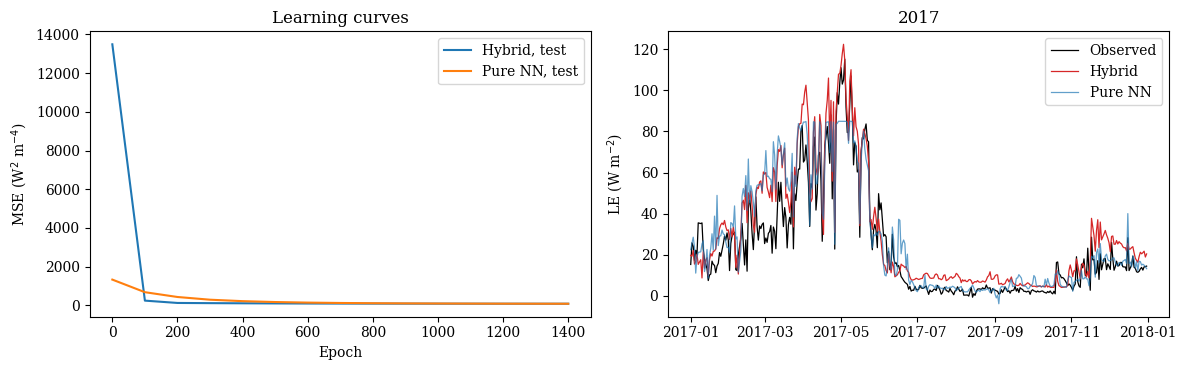

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
axs[0].plot(h_hist['epoch'], h_hist['test_mse'], label='Hybrid, test'); axs[0].plot(p_hist['epoch'], p_hist['test_mse'], label='Pure NN, test')
axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('MSE (W$^2$ m$^{-4}$)'); axs[0].legend(); axs[0].set_title('Learning curves')
sl = slice('2017-01-01', '2017-12-31'); idx = test.loc[sl].index; pos = test.index.get_indexer(idx)
axs[1].plot(idx, test.loc[sl, 'LE'], 'k', lw=0.9, label='Observed'); axs[1].plot(idx, le_h.numpy()[pos], 'tab:red', lw=0.9, label='Hybrid'); axs[1].plot(idx, le_p.numpy()[pos], 'tab:blue', lw=0.9, alpha=0.7, label='Pure NN')
axs[1].set_ylabel('LE (W m$^{-2}$)'); axs[1].legend(); axs[1].set_title('2017'); plt.tight_layout()

## **Step 3: What did the network learn about surface conductance?**

The hybrid model gives us $g_s$ for every day. Plot it against the drivers we believe control stomata.

Text(0.5, 1.0, 'Surface conductance learned inside Penman-Monteith')

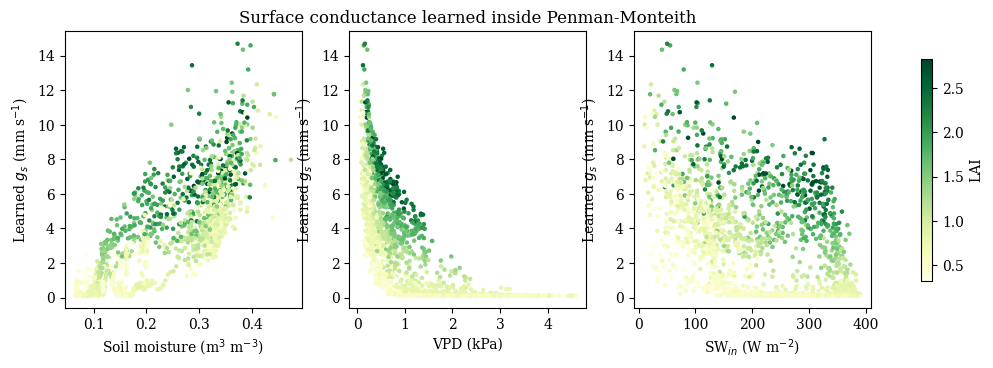

In [6]:
gs_mm = gs_h.numpy() * 1000
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, var, lab in zip(axs, ['SM', 'VPD', 'SW_IN'], ['Soil moisture (m$^3$ m$^{-3}$)', 'VPD (kPa)', 'SW$_{in}$ (W m$^{-2}$)']):
    sc = ax.scatter(test[var], gs_mm, c=test['LAI'], s=5, cmap='YlGn'); ax.set_xlabel(lab); ax.set_ylabel('Learned $g_s$ (mm s$^{-1}$)')
plt.colorbar(sc, ax=axs, label='LAI', shrink=0.8); axs[1].set_title('Surface conductance learned inside Penman-Monteith')

**What to check.** Conductance should rise with soil moisture and LAI and fall with VPD. If it does, the network has
recovered the shape of stomatal response from flux data alone, without being told the functional form. That is the
appeal of the hybrid approach: the learned component is something a plant physiologist can look at and argue with.

## **Step 4: Extrapolation**

Train both models on the cooler 80% of training days and test on the hottest 20% of test days, as in Notebook 08.

In [7]:
q = train['TA'].quantile(0.8); cool = (train['TA'] <= q).values; hot = (test['TA'] > q).values
Xtr_c, Xtr_pc = Xtr[cool], Xtr_p[cool]; ytr_c = ytr[cool]; phys_c = {k_: v[cool] for k_, v in phys_tr.items()}
def train_sub(model, forward, X, y, phys, epochs=1500, lr=5e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        opt.zero_grad(); loss = torch.mean((forward(model, X, phys) - y) ** 2); loss.backward(); opt.step()
    return model
torch.manual_seed(1)
hyb_c = train_sub(HybridPM(), lambda m, x, p: m(x, p)[0], Xtr_c, ytr_c, phys_c)
pure_c = train_sub(PureNN(len(inputs_pure)), lambda m, x, p: m(x), Xtr_pc, ytr_c, None)
with torch.no_grad():
    le_hc = hyb_c(Xte[hot], {k_: v[hot] for k_, v in phys_te.items()})[0]; le_pc = pure_c(Xte_p[hot])
out = pd.DataFrame({'Hybrid': metrics(le_hc, yte[hot]), 'Pure NN': metrics(le_pc, yte[hot])}).T
print(f'Hottest test days (TA > {q:.1f} C, n = {hot.sum()}), models trained on cool days only:'); print(out.round(2))

Hottest test days (TA > 22.6 C, n = 505), models trained on cool days only:
         RMSE   NSE  Bias
Hybrid   9.42  0.71  4.07
Pure NN  8.29  0.77 -1.56


**Read the numbers honestly.** In the run recorded here the pure network matched or slightly beat the hybrid model, both
on the regular test years and on the hot-day extrapolation, and the hybrid carried a small positive bias. That is a real
result, not a failure of the idea: at this site the drivers of LE are well sampled in 16 training years, so a flexible
network has little to gain from the equation, and the daily-mean Penman-Monteith with a neutral aerodynamic
conductance has its own small structural errors that the hybrid model cannot escape. What the hybrid model gives you
that the pure network cannot is the surface conductance in Step 3, a quantity you can compare with leaf-level
measurements and with other models. Reported gains from hybrid models in the literature come mostly from sparse data,
transfer to new sites, and conditions outside the training range. The exercises ask you to test exactly those cases.

## **Exercises**

**Exercise 1.** Remove soil moisture from the network inputs. How much does the hybrid model lose, and does the learned $g_s$ still show a water-stress response through LAI and fPAR?

**Exercise 2.** Add a penalty term to the loss that discourages $g_s$ from changing by more than 20% between consecutive days. Does smoothing help or hurt?

**Exercise 3.** Replace the sigmoid bound on $g_s$ with an unbounded `softplus`. What happens during training, and why is a physically bounded output useful?

**Exercise 4.** Fit the Jarvis-type multiplicative stress model $g_s = g_{max} f(SW) f(VPD) f(\theta)$ with `scipy.optimize` and compare its test NSE with the hybrid model. Which is easier to interpret, and which fits better?

## **References**

- Monteith, J. L. (1965). Evaporation and environment. *Symposia of the Society for Experimental Biology*, 19, 205-234.
- Reichstein, M., et al. (2019). Deep learning and process understanding for data-driven Earth system science. *Nature*, 566, 195-204.
- ElGhawi, R., et al. (2023). Hybrid modeling of evapotranspiration: inferring stomatal and aerodynamic resistances using combined physics-based and machine learning techniques. *Environmental Research Letters*, 18, 034039.
- Raghav, P., Kumar, M., & Liu, Y. (2024). Structural constraints in current stomatal conductance models preclude accurate prediction of evapotranspiration. *Water Resources Research*, 60, e2024WR037652.